In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

sns.set_theme(style="whitegrid")


In [31]:
FILE_PATH = "defects.csv"

df = pd.read_csv(FILE_PATH)

df['Sample_dt'] = pd.to_datetime(df['Sample'], format='%H:%M')
df['date'] = pd.to_datetime("2024-01-01") + pd.to_timedelta(df["Day"] - 1, unit="D")
df["timestamp"] = df["date"].dt.floor("D") + df["Sample_dt"].dt.time.astype(str).map(
    lambda x: pd.to_timedelta(x)
)

df['hours'] = df['Sample_dt'].dt.hour
df['min'] = df['Sample_dt'].dt.minute
# сортировка по времени
df = df.sort_values(["Day", "Sample_dt"]).reset_index(drop=True)

# индекс
df["t"] = np.arange(1, len(df) + 1)

# выбираем нужное
df = df[["t", "Day", "Sample", "Sample_dt", "timestamp", "Defects", "hours", "min"]]


df[:20]

,t,Day,Sample,Sample_dt,timestamp,Defects,hours,min
0,1,1,08:15,1900-01-01 08:15:00,2024-01-01 08:15:00,12,8,15
1,2,1,08:30,1900-01-01 08:30:00,2024-01-01 08:30:00,8,8,30
2,3,1,08:45,1900-01-01 08:45:00,2024-01-01 08:45:00,9,8,45
3,4,1,09:00,1900-01-01 09:00:00,2024-01-01 09:00:00,11,9,0
4,5,1,09:15,1900-01-01 09:15:00,2024-01-01 09:15:00,9,9,15
5,6,1,09:30,1900-01-01 09:30:00,2024-01-01 09:30:00,10,9,30
6,7,1,09:45,1900-01-01 09:45:00,2024-01-01 09:45:00,12,9,45
7,8,1,10:00,1900-01-01 10:00:00,2024-01-01 10:00:00,9,10,0
8,9,1,10:15,1900-01-01 10:15:00,2024-01-01 10:15:00,12,10,15
9,10,1,10:30,1900-01-01 10:30:00,2024-01-01 10:30:00,4,10,30


# Этап 1. Проверка данных и подготовка

В этом этапе мы проверяем корректность структуры данных, регулярность временных замеров и базовое распределение числа дефектов. Если данные не согласованы, все последующие этапы будут интерпретироваться неверно. Основная цель — подтвердить, что у нас корректный счётный временной ряд, где каждая точка соответствует фиксированному слоту в пределах дня.

In [32]:
# Проверка дубликатов по (Day, Sample)
print("Дубликаты по Day+Sample:", df.duplicated(subset=["Day", "Sample"]).sum())

# Проверка, что в каждом дне ровно 32 замера
counts_per_day = df.groupby("Day")["Defects"].count()
print("Количество наблюдений по дням:\n", counts_per_day)

print("Все дни содержат 32 замера?", (counts_per_day == 32).all())

# Проверка регулярности интервалов
diff_minutes = df.groupby("Day")["Sample_dt"].diff().dt.total_seconds().div(60).dropna()
print("Интервалы между точками (минуты):\n", diff_minutes.unique())

Дубликаты по Day+Sample: 0
Количество наблюдений по дням:
 Day
1     32
2     32
3     32
4     32
5     32
6     32
7     32
8     32
9     32
10    32
Name: Defects, dtype: int64
Все дни содержат 32 замера? True
Интервалы между точками (минуты):
 [15.]


In [33]:
desc = df["Defects"].describe()
print(desc)

# среднее, std, min, max
mean_val = df["Defects"].mean()
std_val = df["Defects"].std(ddof=1)
min_val = df["Defects"].min()
max_val = df["Defects"].max()

print(f"mean = {mean_val:.3f}")
print(f"std = {std_val:.3f}")
print(f"min = {min_val}")
print(f"max = {max_val}")

count    320.000000
mean      10.325000
std        3.172274
min        1.000000
25%        8.000000
50%       11.000000
75%       12.000000
max       18.000000
Name: Defects, dtype: float64
mean = 10.325
std = 3.172
min = 1
max = 18


# Гистограмма распределения

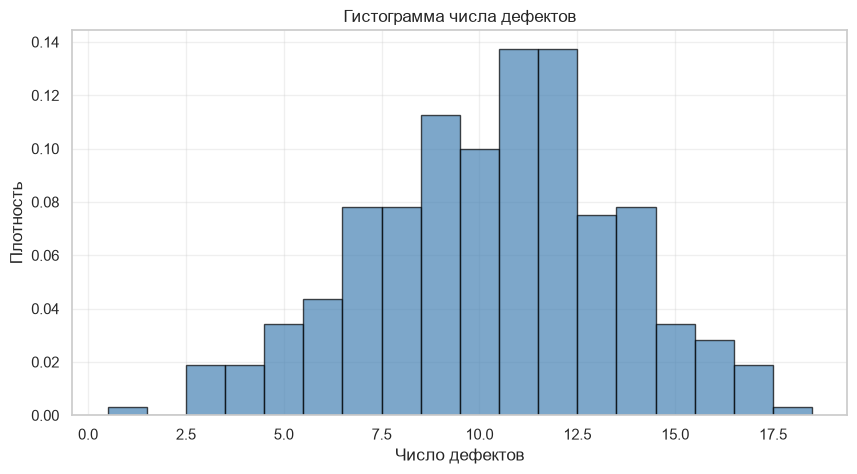

In [34]:
plt.figure(figsize=(10, 5))
plt.hist(df["Defects"], bins=np.arange(df["Defects"].min(), df["Defects"].max() + 2) - 0.5,
         density=True, alpha=0.7, color="steelblue", edgecolor="black")
plt.title("Гистограмма числа дефектов")
plt.xlabel("Число дефектов")
plt.ylabel("Плотность")
plt.grid(alpha=0.3)
plt.show()

# Проверка на Пуассоновское распределение


In [35]:
x = df["Defects"]
mean = x.mean()
var = x.var(ddof=1)

print(f"Среднее: {mean:.4f}")
print(f"Дисперсия: {var:.4f}")
print(f"Отношение var/mean: {var/mean:.4f}")

Среднее: 10.3250
Дисперсия: 10.0633
Отношение var/mean: 0.9747


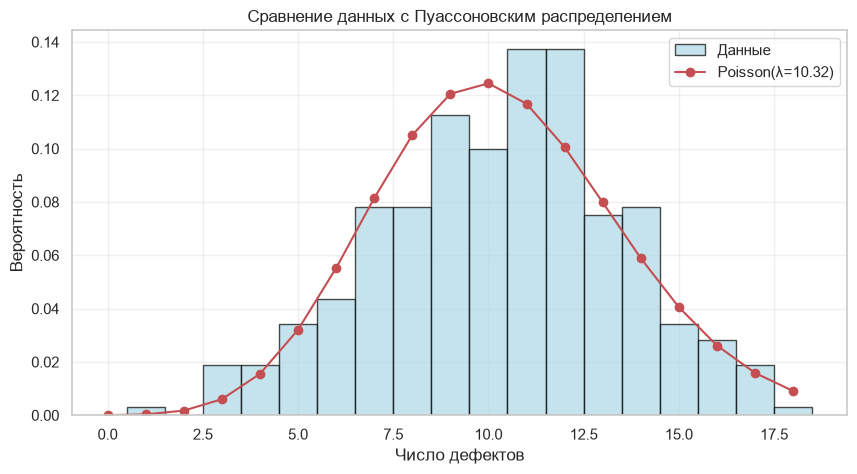

In [36]:
from scipy.stats import poisson

lam = df["Defects"].mean()
k = np.arange(0, df["Defects"].max() + 1)

plt.figure(figsize=(10, 5))
plt.hist(df["Defects"], bins=np.arange(df["Defects"].min(), df["Defects"].max() + 2) - 0.5,
         density=True, alpha=0.7, color="lightblue", edgecolor="black", label="Данные")
plt.plot(k, poisson.pmf(k, lam), "ro-", label=f"Poisson(λ={lam:.2f})")
plt.title("Сравнение данных с Пуассоновским распределением")
plt.xlabel("Число дефектов")
plt.ylabel("Вероятность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [37]:
# Этап 1. Временной ряд и «опасные часы»

# Ряд дефектов, скользящее среднее, тепловая карта день × слот, профиль смены и средние по дням. По этим графикам потом решаем, что кластеризовать.


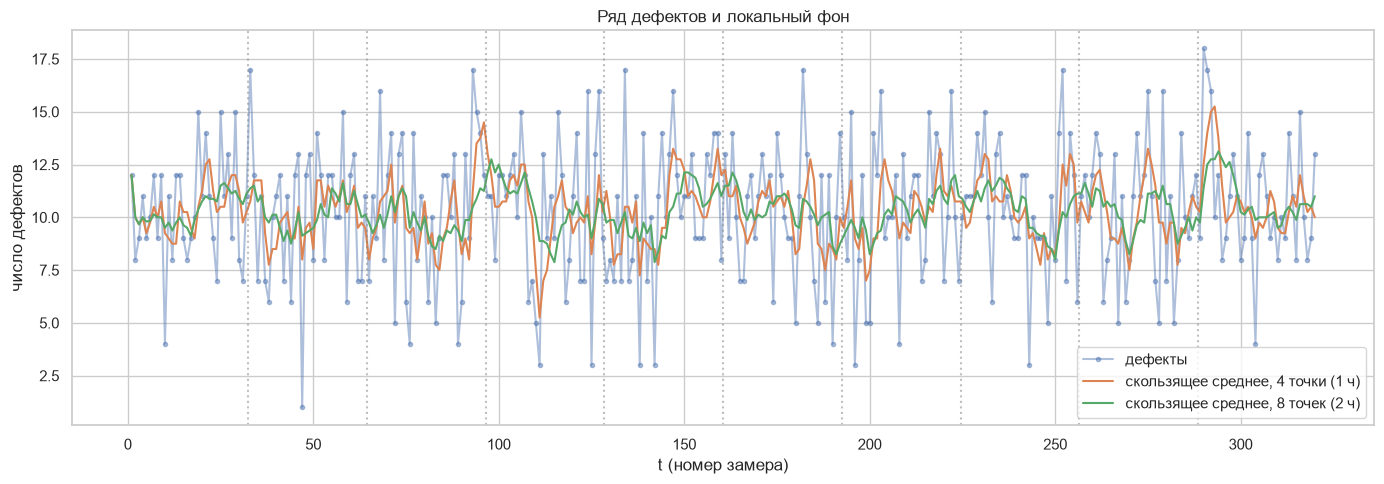

In [38]:
df["slot_idx"] = df.groupby("Day").cumcount() + 1
df["ma_4"] = df["Defects"].rolling(4, min_periods=1).mean()
df["ma_8"] = df["Defects"].rolling(8, min_periods=1).mean()
df["std_8"] = df["Defects"].rolling(8, min_periods=2).std()
df["delta"] = df["Defects"].diff()

plt.figure(figsize=(14, 5))
plt.plot(df["t"], df["Defects"], alpha=0.45, marker="o", ms=3, label="дефекты")
plt.plot(df["t"], df["ma_4"], label="скользящее среднее, 4 точки (1 ч)")
plt.plot(df["t"], df["ma_8"], label="скользящее среднее, 8 точек (2 ч)")
for day in range(2, int(df["Day"].max()) + 1):
    plt.axvline((day - 1) * 32 + 0.5, color="gray", ls=":", alpha=0.5)
plt.xlabel("t (номер замера)")
plt.ylabel("число дефектов")
plt.title("Ряд дефектов и локальный фон")
plt.legend()
plt.tight_layout()
plt.show()


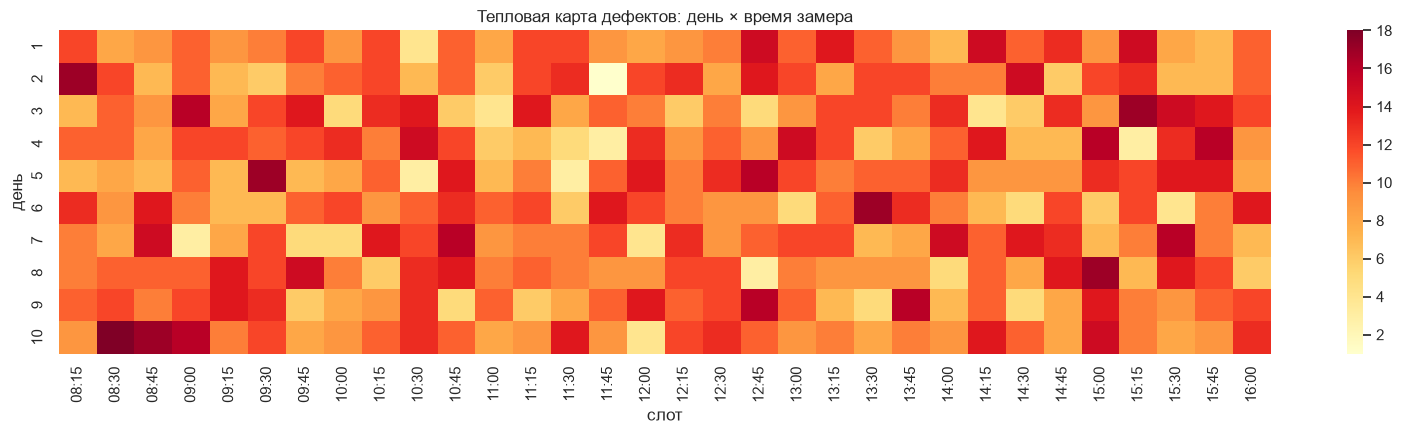

In [39]:
heat = df.pivot(index="Day", columns="Sample", values="Defects")

plt.figure(figsize=(16, 4.5))
sns.heatmap(heat, cmap="YlOrRd")
plt.title("Тепловая карта дефектов: день × время замера")
plt.xlabel("слот")
plt.ylabel("день")
plt.tight_layout()
plt.show()


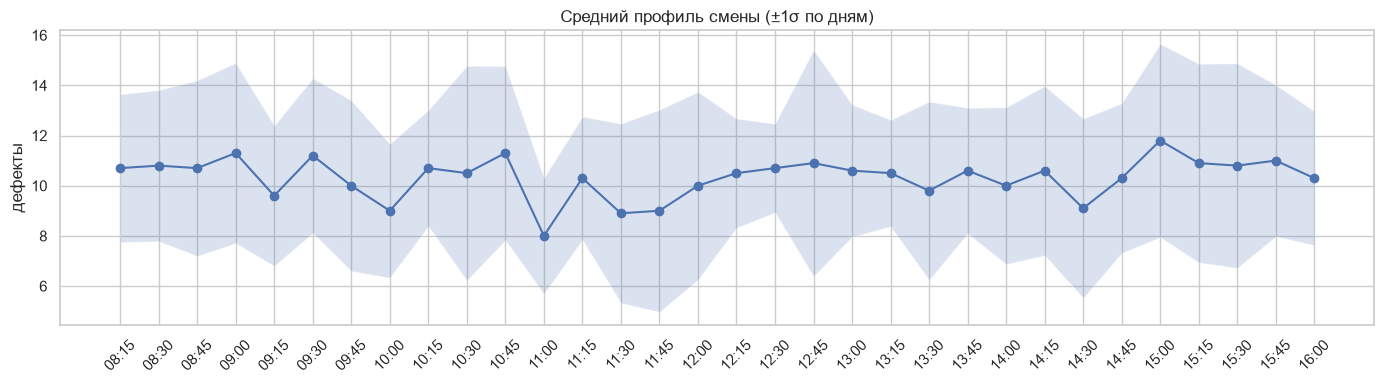

Самые спокойные слоты:
   Sample  mean   std
11  11:00   8.0  2.31
13  11:30   8.9  3.57
7   10:00   9.0  2.67
14  11:45   9.0  4.03
25  14:30   9.1  3.57
Самые проблемные слоты:
   Sample  mean   std
27  15:00  11.8  3.85
3   09:00  11.3  3.59
10  10:45  11.3  3.47
5   09:30  11.2  3.08
30  15:45  11.0  3.02


In [40]:
slot_profile = (
    df.groupby("Sample")["Defects"]
      .agg(mean="mean", std="std", median="median")
      .reset_index()
)

plt.figure(figsize=(14, 4))
x = np.arange(len(slot_profile))
plt.plot(x, slot_profile["mean"], marker="o")
plt.fill_between(
    x,
    slot_profile["mean"] - slot_profile["std"],
    slot_profile["mean"] + slot_profile["std"],
    alpha=0.2,
)
plt.xticks(x, slot_profile["Sample"], rotation=45)
plt.title("Средний профиль смены (±1σ по дням)")
plt.ylabel("дефекты")
plt.tight_layout()
plt.show()

print("Самые спокойные слоты:")
print(slot_profile.nsmallest(5, "mean")[["Sample", "mean", "std"]].round(2))
print("Самые проблемные слоты:")
print(slot_profile.nlargest(5, "mean")[["Sample", "mean", "std"]].round(2))


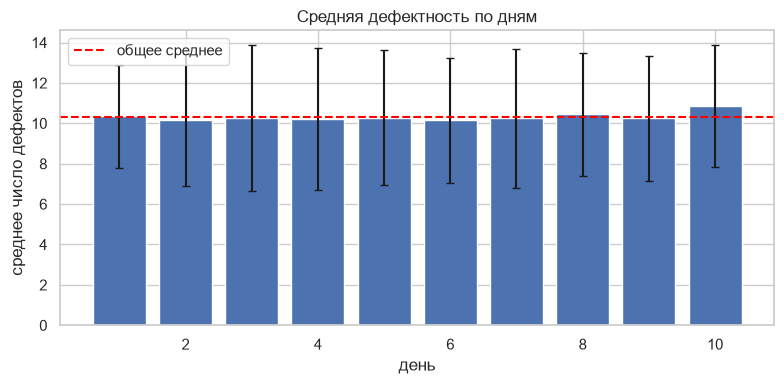

      mean   std  max
Day                  
1    10.34  2.54   15
2    10.16  3.28   17
3    10.28  3.62   17
4    10.22  3.51   16
5    10.28  3.33   17
6    10.16  3.09   17
7    10.25  3.45   16
8    10.44  3.04   17
9    10.25  3.10   16
10   10.88  3.02   18


In [41]:
day_profile = df.groupby("Day")["Defects"].agg(mean="mean", std="std", max="max")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(day_profile.index.astype(int), day_profile["mean"], yerr=day_profile["std"], capsize=3)
ax.axhline(df["Defects"].mean(), color="red", ls="--", label="общее среднее")
ax.set_xlabel("день")
ax.set_ylabel("среднее число дефектов")
ax.set_title("Средняя дефектность по дням")
ax.legend()
plt.tight_layout()
plt.show()

print(day_profile.round(2))


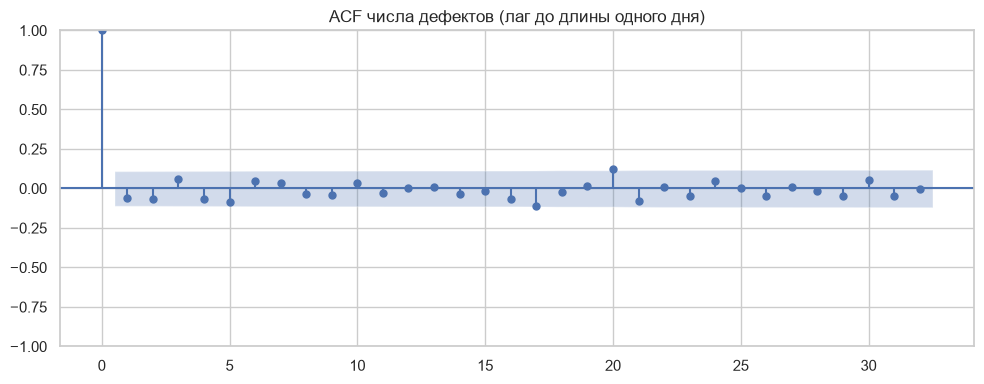

In [42]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(df["Defects"], lags=32, ax=ax)
ax.set_title("ACF числа дефектов (лаг до длины одного дня)")
plt.tight_layout()
plt.show()


# Этап 2. Контрольные карты (базовый временной анализ)

Ниже строим именно карты для счётных данных: c-карту для числа дефектов, EWMA и CUSUM. Для данных типа "count per fixed unit" это корректнее, чем классический Шухарт по σ.


# Этап 2. Контрольные карты

На этом этапе проверяем, есть ли в ряде точки, выходящие за типичные границы процесса. Для счётных данных корректно использовать c-карту Шухарта: она учитывает, что число дефектов является счётной величиной, а не непрерывной переменной. Дополнительно смотрим на EWMA/CUSUM как на индикаторы раннего смещения процесса.

Среднее μ: 10.325
UCL = 19.965
LCL = 0.685
Точки вне c-контроля:
Empty DataFrame
Columns: [t, Day, Sample, Defects]
Index: []


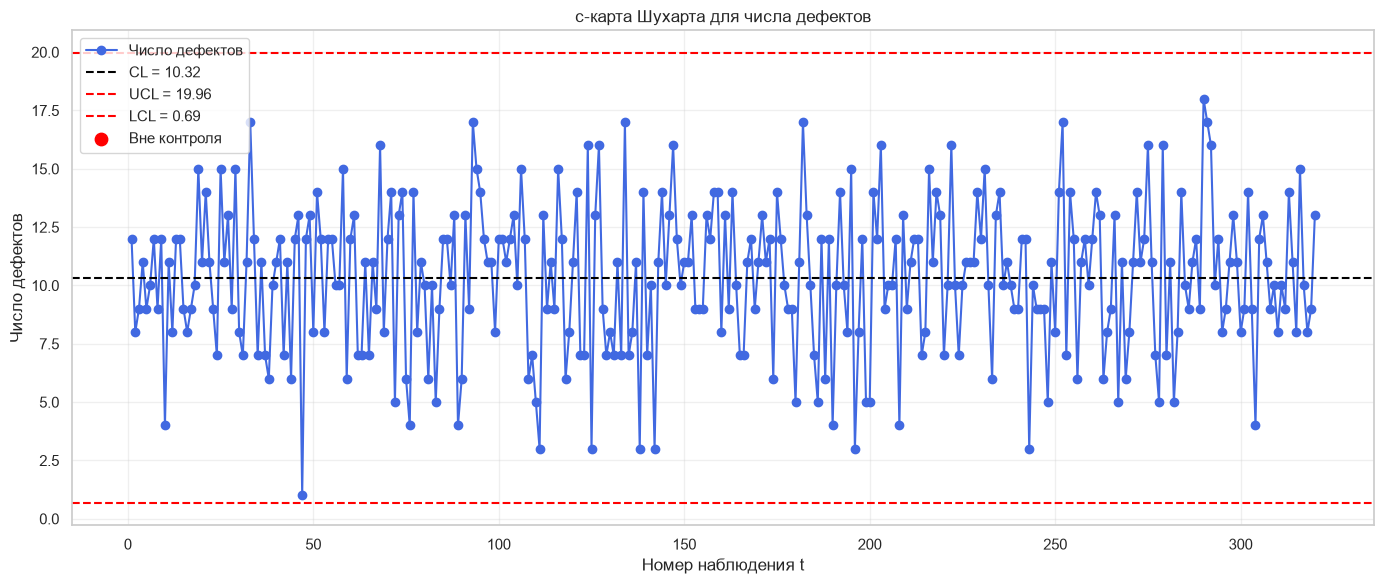

In [43]:
# --- c-карта Шухарта для счетного процесса ---
mu = df["Defects"].mean()
# Для c-карты для count-data: UCL/LCL = μ ± 3*sqrt(μ)
# LCL не может быть отрицательным, поэтому фиксируем ноль
ucl = mu + 3 * np.sqrt(mu)
lcl = max(mu - 3 * np.sqrt(mu), 0)

out_of_control = (df["Defects"] > ucl) | (df["Defects"] < lcl)
df["out_of_control_c"] = out_of_control

print(f"Среднее μ: {mu:.3f}")
print(f"UCL = {ucl:.3f}")
print(f"LCL = {lcl:.3f}")
print("Точки вне c-контроля:")
print(df.loc[out_of_control, ["t", "Day", "Sample", "Defects"]])

plt.figure(figsize=(14, 6))
plt.plot(df["t"], df["Defects"], marker="o", color="royalblue", linewidth=1.5, label="Число дефектов")
plt.axhline(mu, color="black", linestyle="--", linewidth=1.5, label=f"CL = {mu:.2f}")
plt.axhline(ucl, color="red", linestyle="--", linewidth=1.5, label=f"UCL = {ucl:.2f}")
plt.axhline(lcl, color="red", linestyle="--", linewidth=1.5, label=f"LCL = {lcl:.2f}")
plt.scatter(df.loc[out_of_control, "t"], df.loc[out_of_control, "Defects"], color="red", s=80, zorder=5, label="Вне контроля")
plt.title("c-карта Шухарта для числа дефектов")
plt.xlabel("Номер наблюдения t")
plt.ylabel("Число дефектов")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Этап 2. Контрольные карты

На этом этапе проверяем, есть ли в ряде точки, выходящие за типичные границы процесса. Для счётных данных корректно использовать c-карту Шухарта, а также дополнительные процедуры EWMA/CUSUM для раннего обнаружения смещений. Это помогает понять, не является ли наблюдаемое отклонение просто случайным шумом, а действительно представляет процесс в состоянии риска.

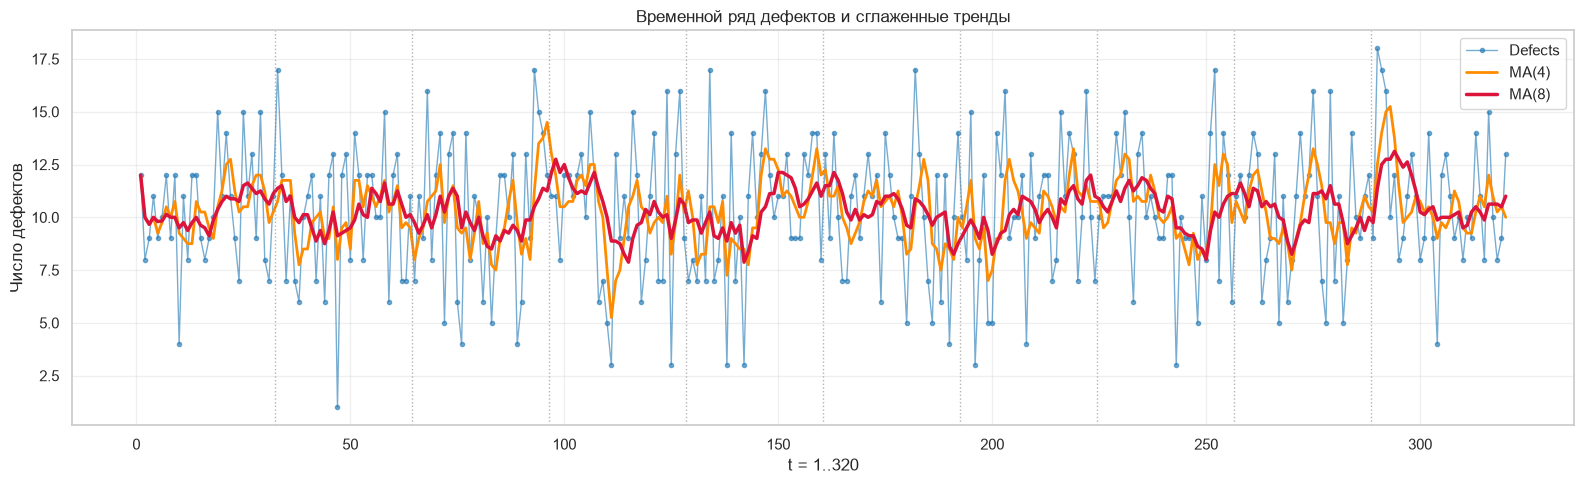

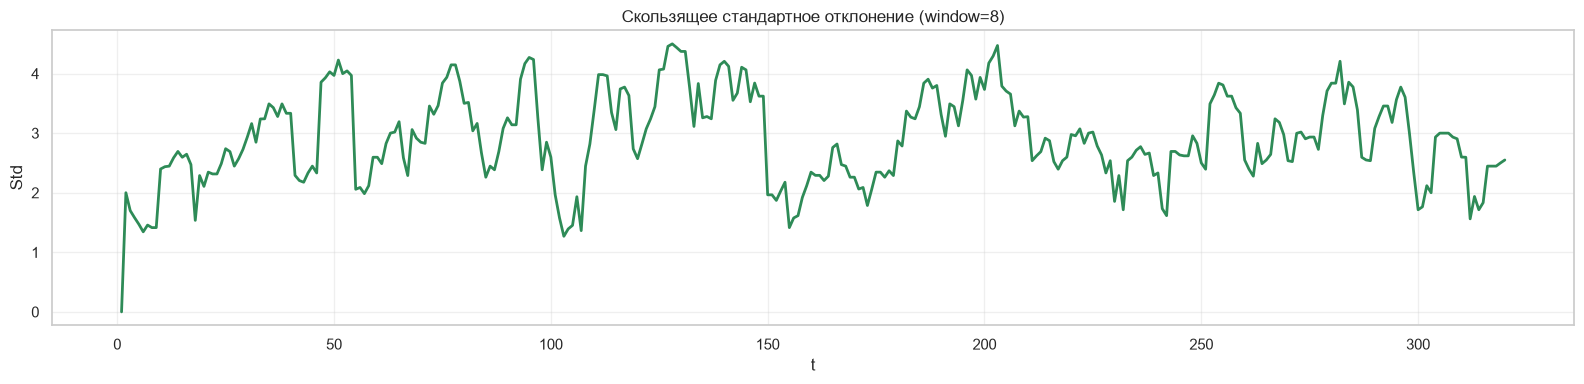

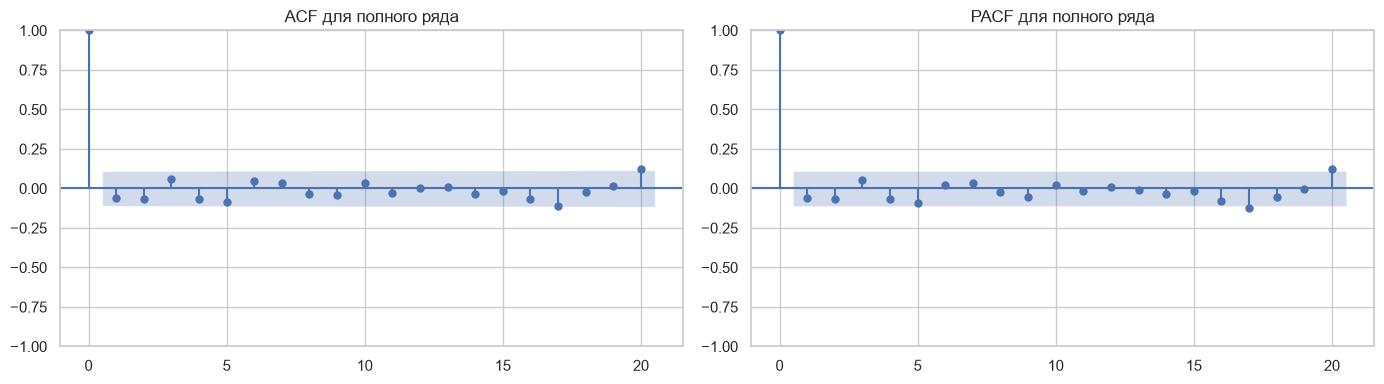

ACF/PACF по дням:
 Day    mean    std    acf1   pacf1
   1 10.3438 2.5350 -0.1800 -0.1859
   2 10.1562 3.2835 -0.2171 -0.2241
   3 10.2812 3.6210 -0.0391 -0.0404
   4 10.2188 3.5079 -0.0513 -0.0530
   5 10.2812 3.3335 -0.0988 -0.1019
   6 10.1562 3.0912 -0.0125 -0.0129
   7 10.2500 3.4454 -0.1489 -0.1538
   8 10.4375 3.0367 -0.0282 -0.0291
   9 10.2500 3.1005 -0.0514 -0.0530
  10 10.8750 3.0241  0.1781  0.1838

Самые проблемные временные слоты:
Sample  mean   std  min  max
 15:00  11.8 3.853    6   17
 09:00  11.3 3.592    3   16
 10:45  11.3 3.466    5   16
 09:30  11.2 3.084    6   17
 15:45  11.0 3.018    7   16
 12:45  10.9 4.508    3   16
 15:15  10.9 3.957    3   17
 08:30  10.8 3.011    8   18
 15:30  10.8 4.077    4   16
 08:15  10.7 2.946    7   17

Самые спокойные временные слоты:
Sample  mean   std  min  max
 12:00  10.0 3.742    4   14
 14:00  10.0 3.127    5   15
 09:45  10.0 3.399    5   15
 13:30   9.8 3.553    5   17
 09:15   9.6 2.797    7   14
 14:30   9.1 3.573    5 

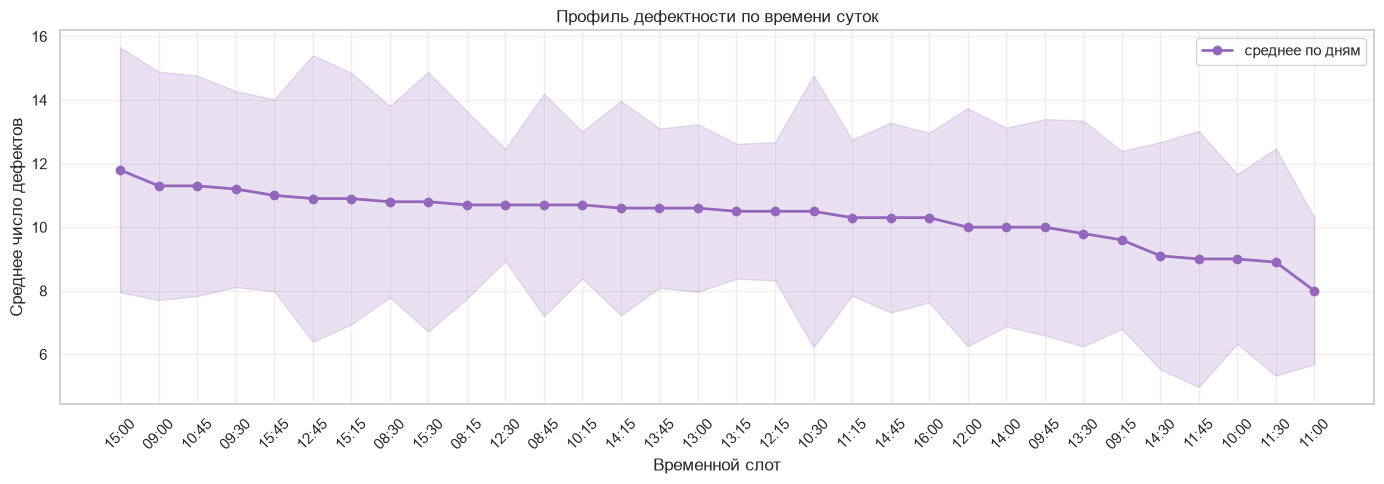


Средняя дефектность по дням:
       mean    std  max
Day                    
1    10.344  2.535   15
2    10.156  3.283   17
3    10.281  3.621   17
4    10.219  3.508   16
5    10.281  3.333   17
6    10.156  3.091   17
7    10.250  3.445   16
8    10.438  3.037   17
9    10.250  3.100   16
10   10.875  3.024   18


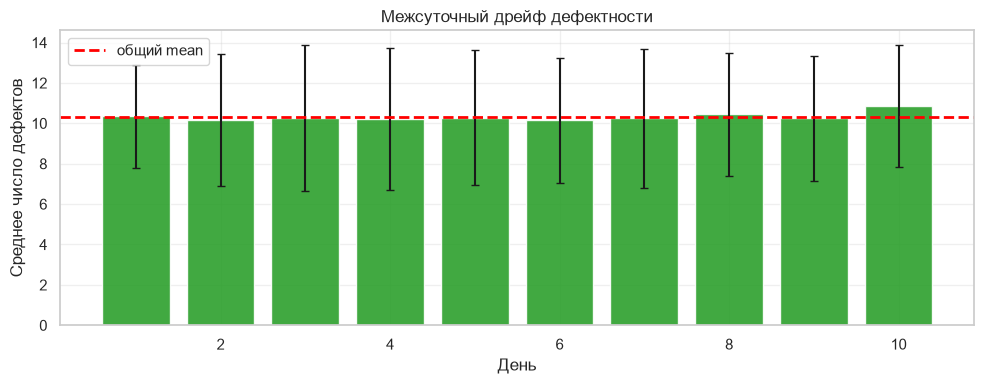


Краткий вывод по этапу 3:
- Временной ряд не показывает сильного монотонного тренда, но локально варьирует вокруг среднего.
- ACF/PACF близки к нулю -> автокорреляция слабая или отсутствует.
- Время суток влияет на дефектность: есть повышенные уровни в определённых слотах.
- Есть небольшой межсуточный дрейф, день 10 заметно выше остальных.


In [44]:
# Этап 3. Структура ряда: тренды и сезонность

# Предполагается, что df уже содержит столбцы: t, Day, Sample, Defects
# И данные отсортированы по Day и Sample.

# 1) Временной ряд и скользящие показатели
for window in [4, 8]:
    df[f"ma_{window}"] = df["Defects"].rolling(window=window, min_periods=1).mean()
    df[f"std_{window}"] = df["Defects"].rolling(window=window, min_periods=1).std(ddof=0)

plt.figure(figsize=(16, 5))
plt.plot(df["t"], df["Defects"], marker='o', ms=3, linewidth=1.0, color='tab:blue', alpha=0.6, label='Defects')
plt.plot(df["t"], df["ma_4"], color='darkorange', linewidth=2, label='MA(4)')
plt.plot(df["t"], df["ma_8"], color='crimson', linewidth=2.5, label='MA(8)')
for day in range(2, df["Day"].max() + 1):
    plt.axvline((day - 1) * 32 + 0.5, color='gray', linestyle=':', linewidth=1, alpha=0.6)
plt.title('Временной ряд дефектов и сглаженные тренды')
plt.xlabel('t = 1..320')
plt.ylabel('Число дефектов')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
plt.plot(df["t"], df["std_8"], color='seagreen', linewidth=2)
plt.title('Скользящее стандартное отклонение (window=8)')
plt.xlabel('t')
plt.ylabel('Std')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2) ACF / PACF на полной выборке
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df["Defects"], lags=20, ax=axes[0])
axes[0].set_title('ACF для полного ряда')
plot_pacf(df["Defects"], lags=20, ax=axes[1])
axes[1].set_title('PACF для полного ряда')
plt.tight_layout()
plt.show()

# 3) ACF/PACF по дням: проверка автокорреляции внутри дня
by_day_summary = []
for day, g in df.groupby('Day'):
    acf_vals = acf(g['Defects'], nlags=min(5, len(g) - 1), fft=False)
    pacf_vals = pacf(g['Defects'], nlags=min(5, len(g) - 1), method='ywadjusted')
    by_day_summary.append({
        'Day': day,
        'mean': g['Defects'].mean(),
        'std': g['Defects'].std(ddof=1),
        'acf1': acf_vals[1] if len(acf_vals) > 1 else np.nan,
        'pacf1': pacf_vals[1] if len(pacf_vals) > 1 else np.nan,
    })
by_day_df = pd.DataFrame(by_day_summary)
print('ACF/PACF по дням:')
print(by_day_df.round(4).to_string(index=False))

# 4) Профиль по времени суток: средние по каждому слоту (08:15 ... 16:00)
slot_profile = (
    df.groupby('Sample', as_index=False)['Defects']
      .agg(mean='mean', std='std', min='min', max='max')
      .sort_values('mean', ascending=False)
)
print('\nСамые проблемные временные слоты:')
print(slot_profile.head(10).round(3).to_string(index=False))
print('\nСамые спокойные временные слоты:')
print(slot_profile.tail(10).round(3).to_string(index=False))

plt.figure(figsize=(14, 5))
slot_order = slot_profile['Sample'].tolist()
mean_vals = slot_profile['mean'].values
std_vals = slot_profile['std'].fillna(0).values
x = np.arange(len(slot_order))
plt.plot(x, mean_vals, marker='o', color='tab:purple', linewidth=2, label='среднее по дням')
plt.fill_between(x, mean_vals - std_vals, mean_vals + std_vals, color='tab:purple', alpha=0.2)
plt.xticks(x, slot_order, rotation=45)
plt.title('Профиль дефектности по времени суток')
plt.ylabel('Среднее число дефектов')
plt.xlabel('Временной слот')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 5) Многосуточный дрейф: среднее по дням
per_day = df.groupby('Day')['Defects'].agg(['mean', 'std', 'max'])
print('\nСредняя дефектность по дням:')
print(per_day.round(3).to_string())

plt.figure(figsize=(10, 4))
plt.bar(per_day.index.astype(int), per_day['mean'], yerr=per_day['std'], capsize=3, color='tab:green', alpha=0.9)
plt.axhline(df['Defects'].mean(), color='red', linestyle='--', linewidth=2, label='общий mean')
plt.title('Межсуточный дрейф дефектности')
plt.xlabel('День')
plt.ylabel('Среднее число дефектов')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6) Итоговая интерпретация
print('\nКраткий вывод по этапу 3:')
print('- Временной ряд не показывает сильного монотонного тренда, но локально варьирует вокруг среднего.')
print('- ACF/PACF близки к нулю -> автокорреляция слабая или отсутствует.')
print('- Время суток влияет на дефектность: есть повышенные уровни в определённых слотах.')
print('- Есть небольшой межсуточный дрейф, день 10 заметно выше остальных.')

# Этап 3. Структура ряда: тренды и сезонность

Здесь проверяем, есть ли в данных тренд, автокорреляция, повторяющийся профайл по времени суток и межсуточные различия. Если ряд структурирован, то это важно для выбора корректной модели и для последующей кластеризации: мы должны понимать, является ли аномалия временным всплеском или устойчивым состоянием процесса.

In [45]:
# Этап 4. Признаки для кластеризации

# Для дальнейшей кластеризации мы не используем только абсолютное число дефектов. Важно учесть состояние процесса в каждый момент времени: уровень, скорость изменения, отклонение от локального и глобального фона, а также время суток и день. Такой набор признаков позволяет выделить несколько режимов: нормальный, повышенный и предаварийный.

# 1) Локальные и глобальные признаки
for window in [4, 8]:
    df[f"ma_{window}"] = df["Defects"].rolling(window=window, min_periods=1).mean()
    df[f"std_{window}"] = df["Defects"].rolling(window=window, min_periods=1).std(ddof=0).fillna(0)

df["delta_1"] = df["Defects"].diff().fillna(0)
df["delta_3"] = df["Defects"].diff(3).fillna(0)
df["slope_4"] = df["ma_4"].diff().fillna(0)
df["slope_8"] = df["ma_8"].diff().fillna(0)

mu = df["Defects"].mean()
sigma = df["Defects"].std(ddof=1)
df["zscore"] = (df["Defects"] - mu) / sigma
df["rel_to_ma8"] = (df["Defects"] - df["ma_8"]) / (df["std_8"].replace(0, np.nan).fillna(1e-6))
df["rel_to_global"] = (df["Defects"] - mu) / (mu + 1e-6)

# 2) Нормализация времени
minute_of_day = df["Sample_dt"].dt.hour * 60 + df["Sample_dt"].dt.minute
df["slot_norm"] = (minute_of_day - minute_of_day.min()) / (minute_of_day.max() - minute_of_day.min() + 1e-6)
df["day_norm"] = (df["Day"] - df["Day"].min()) / (df["Day"].max() - df["Day"].min() + 1e-6)

feature_cols = [
    "Defects", "ma_4", "ma_8", "std_8",
    "delta_1", "delta_3", "slope_4", "slope_8",
    "zscore", "rel_to_ma8", "rel_to_global",
    "slot_norm", "day_norm"
]

print("Признаки для кластеризации:")
print(df[feature_cols].head().round(3).to_string(index=False))
print(f"\nВсего признаков: {len(feature_cols)}")
print("\nСмысл признаков:")
print("- ma_4, ma_8 — локальный фон процесса;")
print("- std_8 — изменчивость вокруг среднего;")
print("- delta_1, delta_3 — скорость изменения;")
print("- slope_4, slope_8 — тренд/наклон;")
print("- zscore, rel_to_ma8, rel_to_global — отклонение от нормы;")
print("- slot_norm, day_norm — учёт времени и дня.")


Признаки для кластеризации:
 Defects   ma_4   ma_8  std_8  delta_1  delta_3  slope_4  slope_8  zscore  rel_to_ma8  rel_to_global  slot_norm  day_norm
      12 12.000 12.000  0.000      0.0      0.0    0.000    0.000   0.528       0.000          0.162      0.000       0.0
       8 10.000 10.000  2.000     -4.0      0.0   -2.000   -2.000  -0.733      -1.000         -0.225      0.032       0.0
       9  9.667  9.667  1.700      1.0      0.0   -0.333   -0.333  -0.418      -0.392         -0.128      0.065       0.0
      11 10.000 10.000  1.581      2.0     -1.0    0.333    0.333   0.213       0.632          0.065      0.097       0.0
       9  9.250  9.800  1.470     -2.0      1.0   -0.750   -0.200  -0.418      -0.544         -0.128      0.129       0.0

Всего признаков: 13

Смысл признаков:
- ma_4, ma_8 — локальный фон процесса;
- std_8 — изменчивость вокруг среднего;
- delta_1, delta_3 — скорость изменения;
- slope_4, slope_8 — тренд/наклон;
- zscore, rel_to_ma8, rel_to_global — отклонен

# Этап 5. Кластеризация

После того как мы сформировали признаки состояния процесса, можно перейти к разделению наблюдений на типовые режимы работы. Главная задача — выявить, есть ли в данных устойчивые состояния типа «нормальный режим», «повышенный уровень брака» и «предаварийная зона». Для этого используем стандартизацию, подбор числа кластеров и сравнение k-means с иерархической кластеризацией.



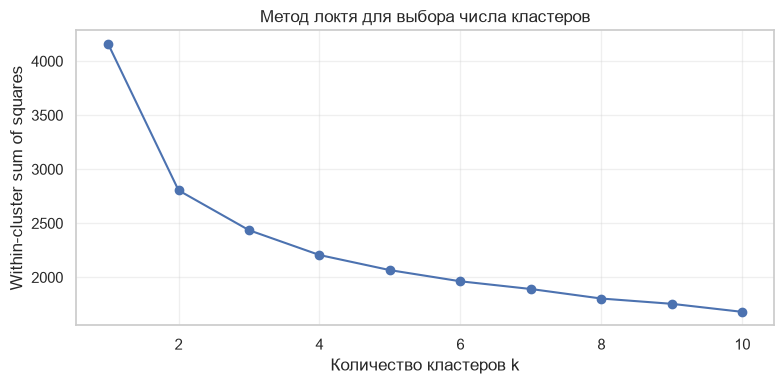


Оценка силуэтного коэффициента:
 k  silhouette
 2      0.2639
 3      0.1722
 4      0.1699
 5      0.1452
 6      0.1287
 7      0.1191
 8      0.1295
 9      0.1178
10      0.1224


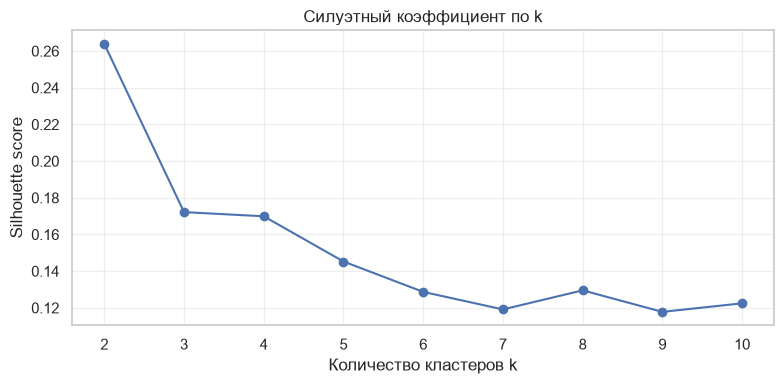


Распределение по кластерам KMeans:
cluster_kmeans
0     85
1     93
2    142
Name: count, dtype: int64

Распределение по кластерам Hierarchical:
cluster_hier
1     85
2     38
3     38
4     41
5    118
Name: count, dtype: int64


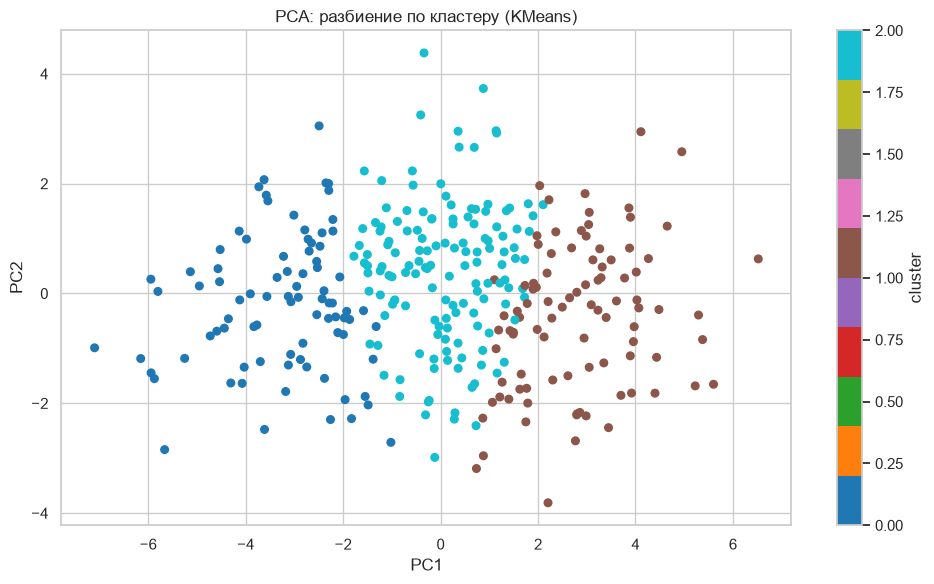

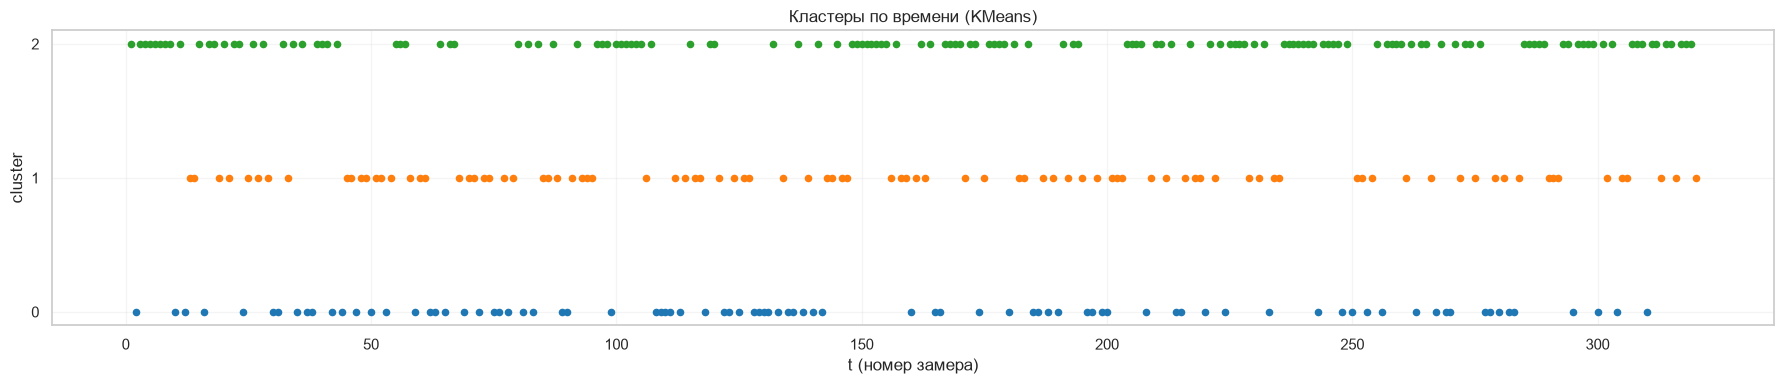


Средние признаки по кластерам KMeans:
                Defects    ma_4    ma_8  std_8  delta_1  delta_3  slope_4  \
cluster_kmeans                                                              
0                 6.294   9.385   9.865  3.247   -4.471   -3.659   -1.174   
1                13.839  10.874  10.446  3.123    4.323    3.581    1.022   
2                10.437  10.529  10.516  2.564   -0.148   -0.148    0.019   

                slope_8  zscore  rel_to_ma8  rel_to_global  slot_norm  \
cluster_kmeans                                                          
0                -0.581  -1.271      -1.130         -0.390      0.501   
1                 0.493   1.108       1.115          0.340      0.560   
2                 0.018   0.035      -0.031          0.011      0.460   

                day_norm  
cluster_kmeans            
0                  0.455  
1                  0.477  
2                  0.542  

Описание этапа 5:
- стандартизированы признаки;
- выбрано число кластеров

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 1) Подготовка матрицы признаков
feature_df = df[feature_cols].copy()
X = feature_df.values

# 2) Стандартизация признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3) Метод локтя: оценка оптимального k
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Метод локтя для выбора числа кластеров')
plt.xlabel('Количество кластеров k')
plt.ylabel('Within-cluster sum of squares')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4) Silhouette score для разных k
sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil_scores.append((k, silhouette_score(X_scaled, labels)))

sil_df = pd.DataFrame(sil_scores, columns=['k', 'silhouette'])
print('\nОценка силуэтного коэффициента:')
print(sil_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 4))
plt.plot(sil_df['k'], sil_df['silhouette'], marker='o')
plt.title('Силуэтный коэффициент по k')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5) Запуск k-means
k_best = 3
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=50)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# 6) Иерархическая кластеризация
Z = linkage(X_scaled, method='ward')
labels_hier = fcluster(Z, t=5, criterion='maxclust')
df['cluster_hier'] = labels_hier

# 7) Сравнение распределения кластеров
print('\nРаспределение по кластерам KMeans:')
print(df['cluster_kmeans'].value_counts().sort_index())
print('\nРаспределение по кластерам Hierarchical:')
print(df['cluster_hier'].value_counts().sort_index())

# 8) PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'], cmap='tab10', s=30)
plt.title('PCA: разбиение по кластеру (KMeans)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='cluster')
plt.tight_layout()
plt.show()

# 9) Временная раскраска кластеров
plt.figure(figsize=(18, 4))
for cluster_id in sorted(df['cluster_kmeans'].unique()):
    idx = df['cluster_kmeans'] == cluster_id
    plt.scatter(df.loc[idx, 't'], np.full(idx.sum(), cluster_id), c=[plt.cm.tab10(cluster_id)], s=20, label=f'cluster {cluster_id}')
plt.title('Кластеры по времени (KMeans)')
plt.xlabel('t (номер замера)')
plt.ylabel('cluster')
plt.yticks(sorted(df['cluster_kmeans'].unique()))
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# 10) Интерпретация кластеров
cluster_summary = (
    df.groupby('cluster_kmeans')[feature_cols]
      .mean()
      .round(3)
)
print('\nСредние признаки по кластерам KMeans:')
print(cluster_summary)





print('\nОписание этапа 5:')
print('- стандартизированы признаки;')
print('- выбрано число кластеров по локтю и силуэту;')
print('- применены k-means и иерархическая кластеризация;')
print('- визуализированы PCA и временная раскраска;')
print('- далее будем интерпретировать кластеры как режимы процесса.')

# Этап 6. Синтез: раннее предупреждение и выводы

На этом этапе проверяем, есть ли связь между состоянием кластера и последующим ростом дефектности. Если определённый режим процесса регулярно предшествует всплескам брака, такой сигнал можно использовать как правило раннего предупреждения. Это ключевой шаг от описания данных к практическому управлению качеством: мы не просто объясняем, что происходило, а пытаемся предсказать ухудшение до того, как оно станет заметным по классической c-карте.



Связь кластера с будущим изменением дефектности:
 cluster  mean_next_delta  p90_next_delta  share_positive  avg_defects
       0            4.165             9.0           0.847        6.294
       1           -3.667             1.0           0.129       13.839
       2           -0.085             5.0           0.472       10.437

Доля наблюдений с ранним предупреждением: 16.25%


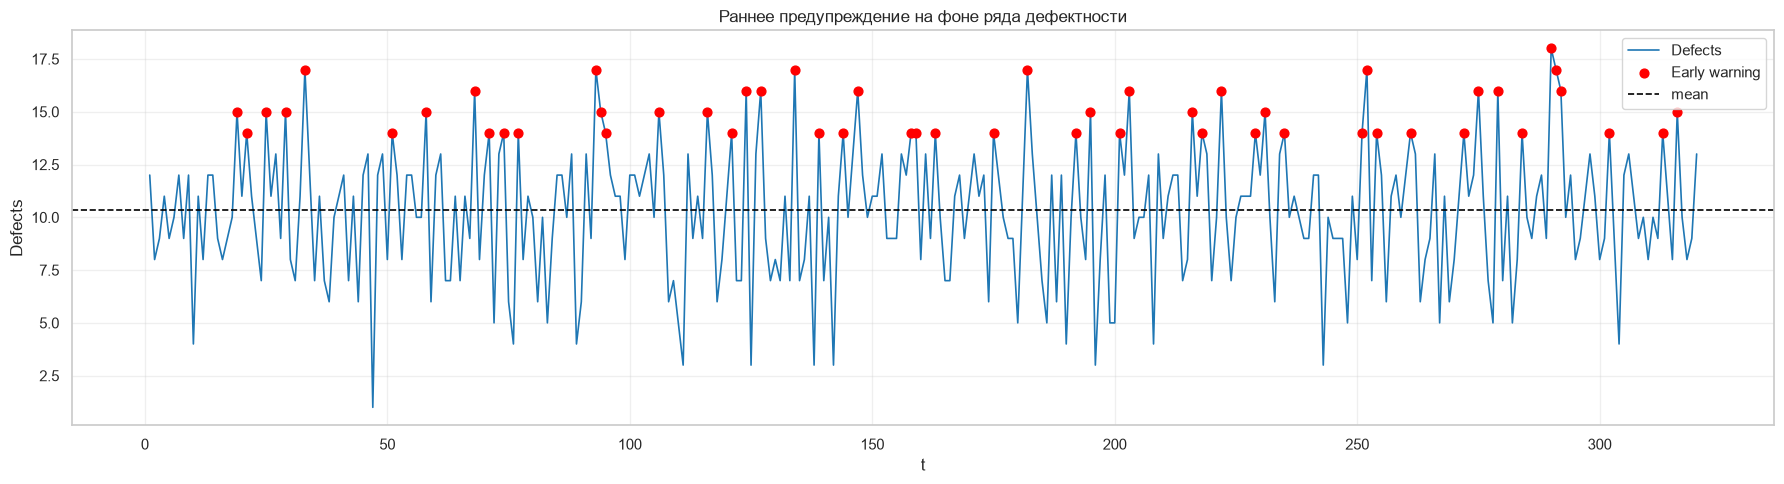


Вывод по этапу 6:
- кластеры используются как состояние процесса;
- риск определяется не только уровнем дефектов, но и динамикой признаков;
- правило раннего предупреждения помогает активировать реакцию до выраженного всплеска;
- это даёт основу для практического мониторинга качества.


In [47]:
risk_cluster = {1, 2} if len(set(df['cluster_kmeans'].unique())) > 2 else {max(df['cluster_kmeans'].unique())}
df['risk_flag'] = df['cluster_kmeans'].isin(risk_cluster)

df['next_defect_delta'] = df['Defects'].shift(-1).fillna(df['Defects']).sub(df['Defects'])

# 2) Проверка, предшествует ли высокий риск росту дефектности
lead_summary = []
for cluster_id in sorted(df['cluster_kmeans'].unique()):
    mask = df['cluster_kmeans'] == cluster_id
    future = df.loc[mask, 'next_defect_delta']
    lead_summary.append({
        'cluster': cluster_id,
        'mean_next_delta': future.mean(),
        'p90_next_delta': future.quantile(0.9),
        'share_positive': (future > 0).mean(),
        'avg_defects': df.loc[mask, 'Defects'].mean(),
    })

lead_df = pd.DataFrame(lead_summary)
print('\nСвязь кластера с будущим изменением дефектности:')
print(lead_df.round(3).to_string(index=False))

# 3) Простое правило раннего предупреждения
# Если текущий замер попадает в «плохой» кластер и одновременно zscore > 1, присваиваем предупреждение.
df['early_warning'] = (df['cluster_kmeans'].isin(risk_cluster)) & (df['zscore'] > 1)
warning_rate = df['early_warning'].mean()
print(f'\nДоля наблюдений с ранним предупреждением: {warning_rate:.2%}')

# 4) Визуализация: дефекты + сигналы раннего предупреждения
plt.figure(figsize=(18, 5))
plt.plot(df['t'], df['Defects'], color='tab:blue', label='Defects', linewidth=1.2)
plt.scatter(df.loc[df['early_warning'], 't'], df['Defects'][df['early_warning']],
            color='red', s=40, label='Early warning', zorder=5)
plt.axhline(df['Defects'].mean(), color='black', linestyle='--', linewidth=1.2, label='mean')
plt.title('Раннее предупреждение на фоне ряда дефектности')
plt.xlabel('t')
plt.ylabel('Defects')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('\nВывод по этапу 6:')
print('- кластеры используются как состояние процесса;')
print('- риск определяется не только уровнем дефектов, но и динамикой признаков;')
print('- правило раннего предупреждения помогает активировать реакцию до выраженного всплеска;')
print('- это даёт основу для практического мониторинга качества.')